#  Detecção de Fraude em Cartão de Crédito

**Projeto prático:** Pipeline completo de detecção de fraude em transações de cartão de crédito.

**Desafio central:** A fraude é extremamente rara (0,17% das transações). Um modelo que sempre prevê "não fraude" teria 99,83% de acurácia, mas seria completamente inútil. Por isso, nosso foco são as métricas de **recall, precisão e F1** para a classe de fraude.

**Fonte do dataset:** Kaggle - Credit Card Fraud Detection

**Colunas:**
- `Time`: segundos decorridos desde a primeira transação no dataset
- `V1` a `V28`: variáveis numéricas obtidas por PCA (protegem privacidade)
- `Amount`: valor da transação
- `Class`: 0 = transação normal, 1 = fraude

## 1. Importar Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    roc_auc_score, precision_recall_curve, f1_score,
    accuracy_score
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap

## 2. Explorar os Dados

In [2]:
df = pd.read_csv('creditcard.csv')
print(f"Shape do dataset: {df.shape}")
print(f"Colunas: {list(df.columns)}")
print(f"\nEstatísticas descritivas:\n{df.describe().T}")

Shape do dataset: (284807, 31)
Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']



Estatísticas descritivas:
           count          mean           std         min           25%  \
Time    284807.0  9.481386e+04  47488.145955    0.000000  54201.500000   
V1      284807.0  1.175161e-15      1.958696  -56.407510     -0.920373   
V2      284807.0  3.384974e-16      1.651309  -72.715728     -0.598550   
V3      284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365   
V4      284807.0  2.094852e-15      1.415869   -5.683171     -0.848640   
V5      284807.0  1.021879e-15      1.380247 -113.743307     -0.691597   
V6      284807.0  1.494498e-15      1.332271  -26.160506     -0.768296   
V7      284807.0 -5.620335e-16      1.237094  -43.557242     -0.554076   
V8      284807.0  1.149614e-16      1.194353  -73.216718     -0.208630   
V9      284807.0 -2.414189e-15      1.098632  -13.434066     -0.643098   
V10     284807.0  2.238554e-15      1.088850  -24.588262     -0.535426   
V11     284807.0  1.724421e-15      1.020713   -4.797473     -0.762494   
V12     284

Distribuição da variável Class:
Class
0    284315
1       492
Name: count, dtype: int64

Taxa de fraude: 0.0017 (0.17%)
Total de transações: 284807
Fraudes: 492
Normais: 284315


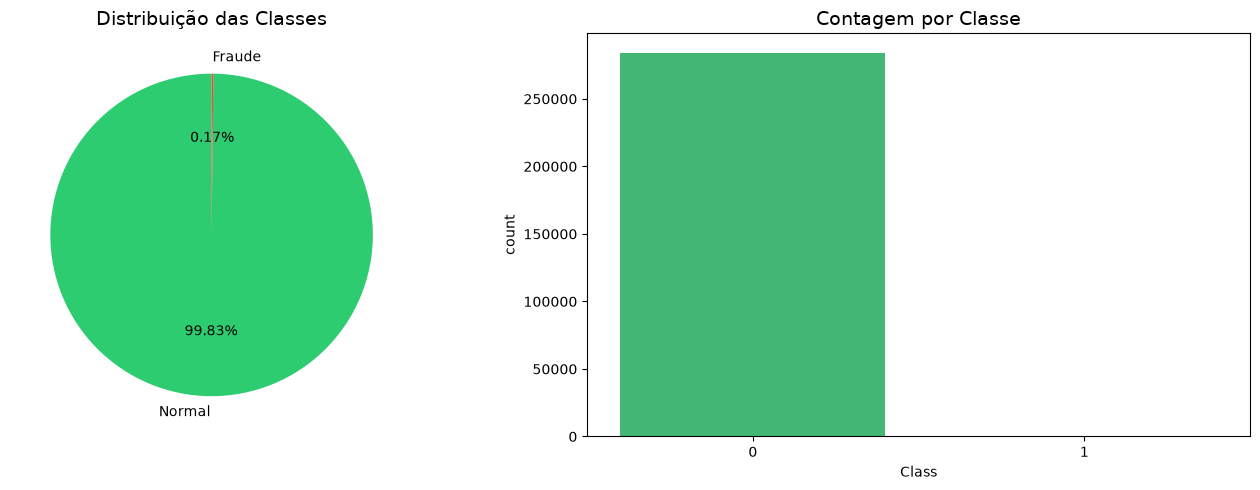

In [3]:
print("Distribuição da variável Class:")
print(df['Class'].value_counts())
print(f"\nTaxa de fraude: {df['Class'].mean():.4f} ({df['Class'].mean()*100:.2f}%)")
print(f"Total de transações: {len(df)}")
print(f"Fraudes: {df['Class'].sum()}")
print(f"Normais: {len(df) - df['Class'].sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie([df['Class'].value_counts()[0], df['Class'].value_counts()[1]],
            labels=['Normal', 'Fraude'],
            autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[0].set_title('Distribuição das Classes', fontsize=14)
sns.countplot(x='Class', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Contagem por Classe', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
print("Valores nulos por coluna:")
print(df.isnull().sum().sum())

correlation_with_class = df.corr()['Class'].drop('Class').sort_values(ascending=False)
print("\nCorrelação com Class (top 10):")
print(correlation_with_class.head(10))

Valores nulos por coluna:
0



Correlação com Class (top 10):
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


## 3. Preparação dos Dados

In [5]:
df['Amount_Log'] = np.log1p(df['Amount'])
df['Time_Log'] = np.log1p(df['Time'])
print(f"Colunas após feature engineering: {len(df.columns)}")

Colunas após feature engineering: 33


In [6]:
X = df.drop(['Class'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_amount = StandardScaler()
scaler_time = StandardScaler()
X_train['Amount_Log'] = scaler_amount.fit_transform(X_train[['Amount_Log']])
X_train['Time_Log'] = scaler_time.fit_transform(X_train[['Time_Log']])
X_test['Amount_Log'] = scaler_amount.transform(X_test[['Amount_Log']])
X_test['Time_Log'] = scaler_time.transform(X_test[['Time_Log']])

print(f"Treino: {X_train.shape[0]} amostras ({y_train.sum()} fraudes)")
print(f"Teste:  {X_test.shape[0]} amostras ({y_test.sum()} fraudes)")
print(f"Proporção fraude no treino: {y_train.mean():.4f}")
print(f"Proporção fraude no teste:  {y_test.mean():.4f}")

Treino: 227845 amostras (394 fraudes)
Teste:  56962 amostras (98 fraudes)
Proporção fraude no treino: 0.0017
Proporção fraude no teste:  0.0017


## 4. Tratamento do Desbalanceamento

In [7]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
print(f"After Undersampling: {X_train_under.shape[0]} samples")
print(f"Fraudes: {y_train_under.sum()}, Normais: {(y_train_under==0).sum()}")
print(f"Proporção: {y_train_under.mean():.4f} (balanceado!)")

smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {X_train_over.shape[0]} samples")
print(f"Fraudes: {y_train_over.sum()}, Normais: {(y_train_over==0).sum()}")
print(f"Proporção: {y_train_over.mean():.4f} (balanceado!)")

After Undersampling: 788 samples
Fraudes: 394, Normais: 394
Proporção: 0.5000 (balanceado!)


After SMOTE: 454902 samples
Fraudes: 227451, Normais: 227451
Proporção: 0.5000 (balanceado!)


## 5. Treinamento e Comparação de Modelos

In [8]:
def train_and_evaluate(X_train, y_train, X_test, y_test, model_name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    print(f"\n{'='*60}")
    print(f"Modelo: {model_name}")
    print(f"{'='*60}")
    print(f"Acurácia:  {acc:.4f}")
    print(f"F1 Score (Fraude): {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    print(f"\nClassificação Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))
    return {'model_name': model_name, 'model': model, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba, 'accuracy': acc, 'f1': f1, 'auc_roc': auc_roc}

# Baseline - Regressão Logística
lr_base = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
results_lr_base = train_and_evaluate(X_train, y_train, X_test, y_test, "LogReg - Baseline", lr_base)

# Baseline - Random Forest
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
results_rf_base = train_and_evaluate(X_train, y_train, X_test, y_test, "RF - Baseline", rf_base)

# Baseline - XGBoost
xgb_base = xgb.XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), eval_metric='logloss')
results_xgb_base = train_and_evaluate(X_train, y_train, X_test, y_test, "XGB - Baseline", xgb_base)


Modelo: LogReg - Baseline
Acurácia:  0.9716
F1 Score (Fraude): 0.0981
AUC-ROC:   0.9679

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
      Fraude       0.05      0.90      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.93      0.54     56962
weighted avg       1.00      0.97      0.98     56962




Modelo: RF - Baseline
Acurácia:  0.9995
F1 Score (Fraude): 0.8571
AUC-ROC:   0.9573

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.93      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962




Modelo: XGB - Baseline
Acurácia:  0.9995
F1 Score (Fraude): 0.8482
AUC-ROC:   0.9726

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
# Undersampling
lr_under = LogisticRegression(random_state=42, max_iter=1000)
results_lr_under = train_and_evaluate(X_train_under, y_train_under, X_test, y_test, "LogReg - Under", lr_under)

rf_under = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_rf_under = train_and_evaluate(X_train_under, y_train_under, X_test, y_test, "RF - Under", rf_under)

xgb_under = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
results_xgb_under = train_and_evaluate(X_train_under, y_train_under, X_test, y_test, "XGB - Under", xgb_under)


Modelo: LogReg - Under
Acurácia:  0.9590
F1 Score (Fraude): 0.0709
AUC-ROC:   0.9730

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     56864
      Fraude       0.04      0.91      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.93      0.52     56962
weighted avg       1.00      0.96      0.98     56962




Modelo: RF - Under
Acurácia:  0.9652
F1 Score (Fraude): 0.0833
AUC-ROC:   0.9779

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     56864
      Fraude       0.04      0.92      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962




Modelo: XGB - Under
Acurácia:  0.9550
F1 Score (Fraude): 0.0657
AUC-ROC:   0.9771

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     56864
      Fraude       0.03      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.96      0.98     56962



In [10]:
# Oversampling com SMOTE
lr_over = LogisticRegression(random_state=42, max_iter=1000)
results_lr_over = train_and_evaluate(X_train_over, y_train_over, X_test, y_test, "LogReg - SMOTE", lr_over)

rf_over = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_rf_over = train_and_evaluate(X_train_over, y_train_over, X_test, y_test, "RF - SMOTE", rf_over)

xgb_over = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
results_xgb_over = train_and_evaluate(X_train_over, y_train_over, X_test, y_test, "XGB - SMOTE", xgb_over)


Modelo: LogReg - SMOTE
Acurácia:  0.9891
F1 Score (Fraude): 0.2214
AUC-ROC:   0.9690

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
      Fraude       0.13      0.90      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962




Modelo: RF - SMOTE
Acurácia:  0.9995
F1 Score (Fraude): 0.8394
AUC-ROC:   0.9645

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.85      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962




Modelo: XGB - SMOTE
Acurácia:  0.9994
F1 Score (Fraude): 0.8317
AUC-ROC:   0.9840

Classificação Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.81      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



## 6. Comparação dos Modelos

Ranking por F1 Score (Fraude):
          model_name  accuracy        f1   auc_roc
1      RF - Baseline  0.999544  0.857143  0.957292
2     XGB - Baseline  0.999491  0.848168  0.972585
3         RF - SMOTE  0.999456  0.839378  0.964523
4        XGB - SMOTE  0.999403  0.831683  0.984024
5     LogReg - SMOTE  0.989133  0.221384  0.969005
6  LogReg - Baseline  0.971578  0.098050  0.967899
7         RF - Under  0.965222  0.083295  0.977864
8     LogReg - Under  0.959043  0.070888  0.973050
9        XGB - Under  0.955040  0.065669  0.977078


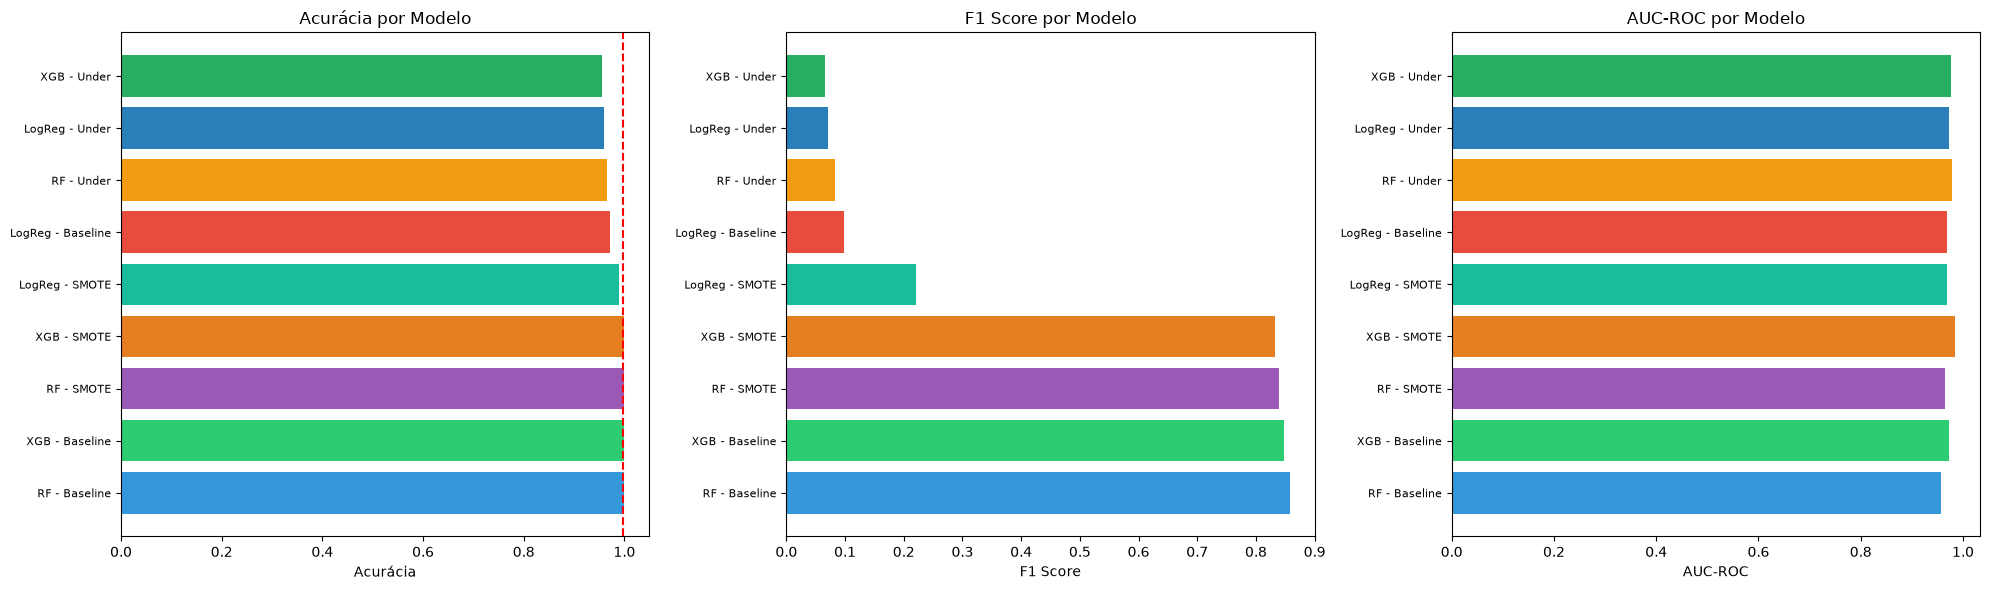

⚠️ A acurácia é enganosa! O F1 Score é a métrica que importa.


In [11]:
all_results = [results_lr_base, results_rf_base, results_xgb_base,
               results_lr_under, results_rf_under, results_xgb_under,
               results_lr_over, results_rf_over, results_xgb_over]

results_df = pd.DataFrame(all_results)[['model_name', 'accuracy', 'f1', 'auc_roc']]
results_df = results_df.sort_values('f1', ascending=False)
results_df.index = range(1, len(results_df) + 1)

print("Ranking por F1 Score (Fraude):")
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c', '#f39c12', '#2980b9', '#27ae60']
axes[0].barh(range(len(results_df)), results_df['accuracy'], color=colors)
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels(results_df['model_name'], fontsize=8)
axes[0].set_xlabel('Acurácia')
axes[0].set_title('Acurácia por Modelo')
axes[0].axvline(x=0.998, color='red', linestyle='--', label='Baseline')
axes[1].barh(range(len(results_df)), results_df['f1'], color=colors)
axes[1].set_yticks(range(len(results_df)))
axes[1].set_yticklabels(results_df['model_name'], fontsize=8)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('F1 Score por Modelo')
axes[2].barh(range(len(results_df)), results_df['auc_roc'], color=colors)
axes[2].set_yticks(range(len(results_df)))
axes[2].set_yticklabels(results_df['model_name'], fontsize=8)
axes[2].set_xlabel('AUC-ROC')
axes[2].set_title('AUC-ROC por Modelo')
plt.tight_layout()
plt.show()

print("⚠️ A acurácia é enganosa! O F1 Score é a métrica que importa.")

## 7. Curvas de Avaliação

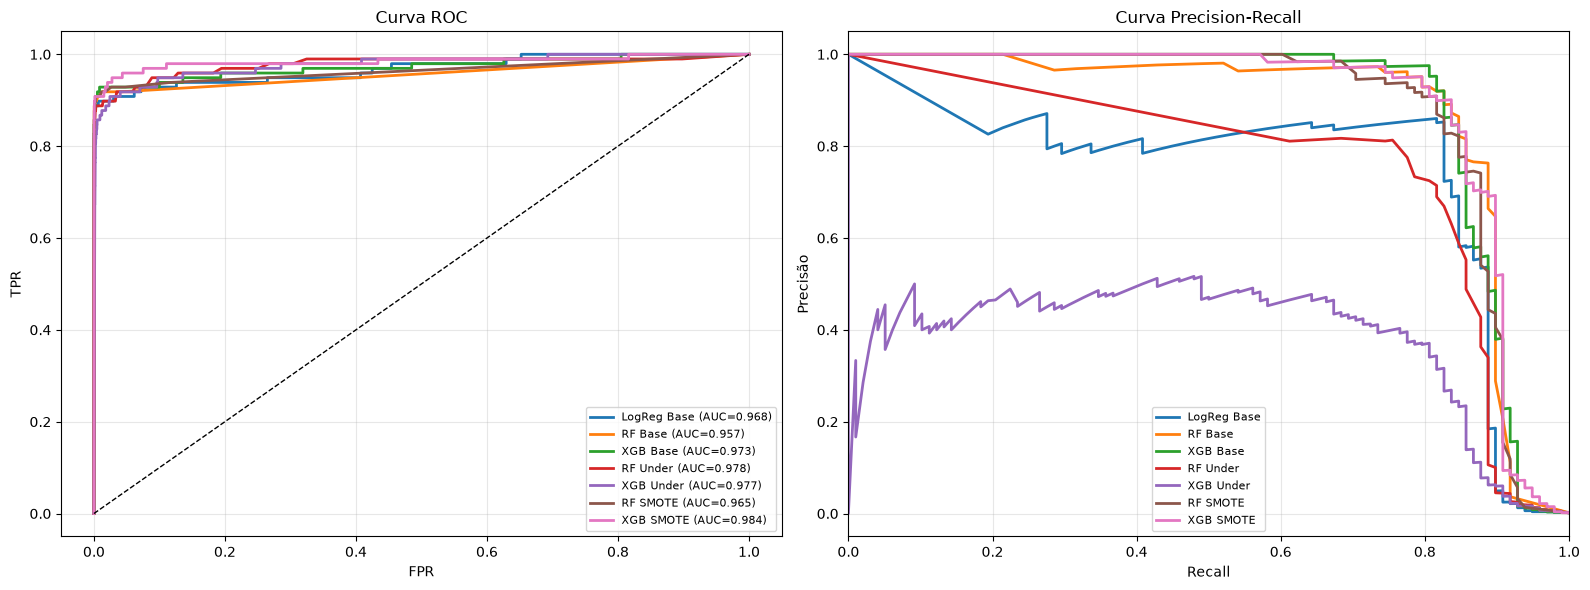

In [12]:
best_models = [("LogReg Base", results_lr_base), ("RF Base", results_rf_base),
               ("XGB Base", results_xgb_base), ("RF Under", results_rf_under),
               ("XGB Under", results_xgb_under), ("RF SMOTE", results_rf_over),
               ("XGB SMOTE", results_xgb_over)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, res in best_models:
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc_roc']:.3f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
for name, res in best_models:
    precision, recall, _ = precision_recall_curve(y_test, res['y_pred_proba'])
    axes[1].plot(recall, precision, label=f"{name}", linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
plt.tight_layout()
plt.show()

## 8. Ajuste do Limiar de Decisão

In [13]:
best_rf = results_rf_under['model']
y_proba = results_rf_under['y_pred_proba']

thresholds = np.arange(0.05, 0.5, 0.01)
best_f1 = 0
best_threshold = 0.5
for t in thresholds:
    y_pred_temp = (y_proba >= t).astype(int)
    f1_temp = f1_score(y_test, y_pred_temp)
    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_threshold = t

print(f"Melhor limiar: {best_threshold:.2f}")
print(f"Melhor F1: {best_f1:.4f}")
print(f"F1 com limiar padrão (0.5): {results_rf_under['f1']:.4f}")

y_pred_optimized = (y_proba >= best_threshold).astype(int)
print(f"\nClassificação com limiar otimizado ({best_threshold:.2f}):")
print(classification_report(y_test, y_pred_optimized, target_names=['Normal', 'Fraude']))

Melhor limiar: 0.49
Melhor F1: 0.0782
F1 com limiar padrão (0.5): 0.0833

Classificação com limiar otimizado (0.49):
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     56864
      Fraude       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



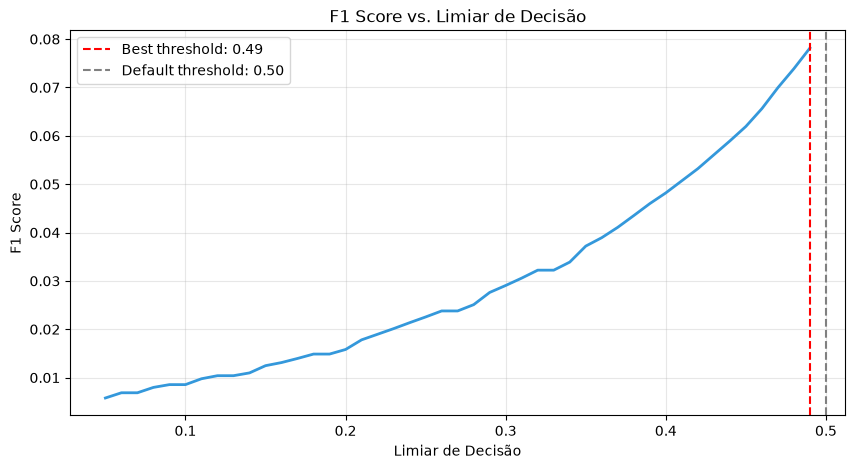

In [14]:
f1_scores = []
for t in thresholds:
    y_pred_temp = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_temp))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color='#3498db', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best threshold: {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold: 0.50')
plt.xlabel('Limiar de Decisão')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Limiar de Decisão')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Importância das Variáveis

Top 15 features mais importantes (Random Forest):
feature  importance
    V14    0.180335
    V12    0.124602
    V10    0.110401
     V4    0.102181
    V17    0.081493
    V16    0.051516
    V11    0.043437
     V7    0.041666
     V3    0.039321
     V2    0.022866
     V9    0.021434
 Amount    0.012744
    V18    0.012725
    V28    0.012375
    V21    0.011520


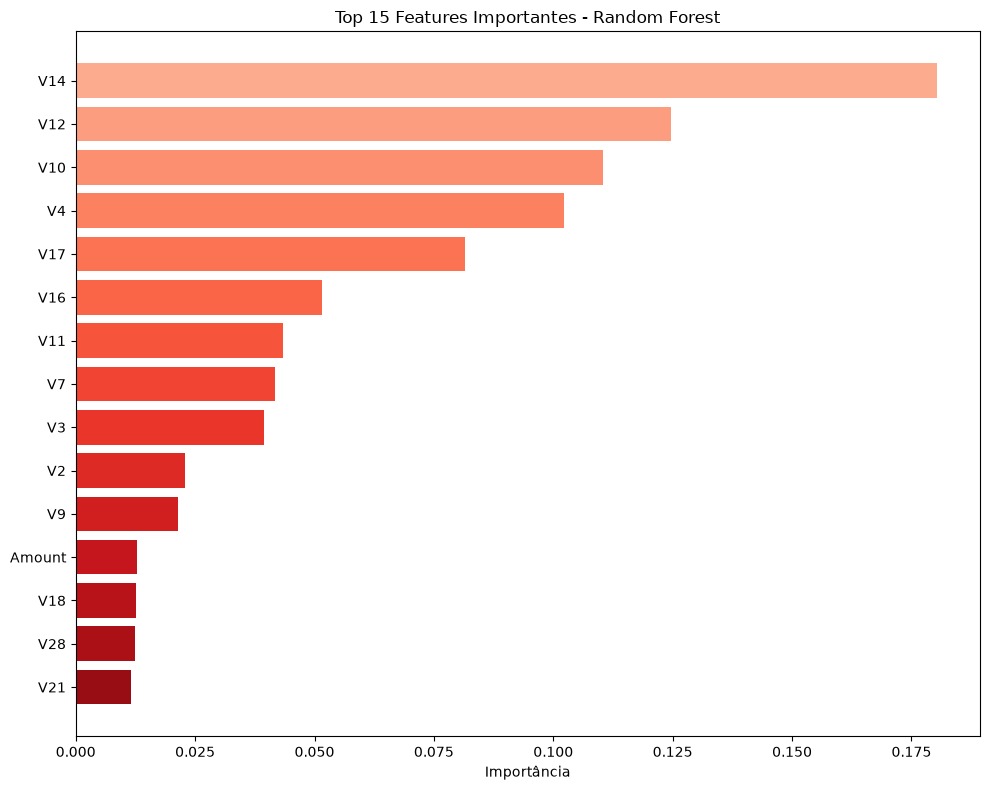

In [15]:
feature_importance = pd.DataFrame({
    'feature': X_train_under.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print("Top 15 features mais importantes (Random Forest):")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 8))
colors_imp = plt.cm.Reds(np.linspace(0.3, 0.9, len(feature_importance)))
plt.barh(range(len(feature_importance)), feature_importance['importance'], color=colors_imp)
plt.yticks(range(len(feature_importance)), feature_importance['feature'], fontsize=10)
plt.xlabel('Importância')
plt.title('Top 15 Features Importantes - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Explicação com SHAP

In [16]:
explainer = shap.TreeExplainer(best_rf)
X_shap = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_fraud = shap_values[:, :, 1]
else:
    shap_values_fraud = shap_values
print(f"SHAP values shape: {shap_values_fraud.shape}")
print("Explicação concluída com sucesso!")

SHAP values shape: (500, 32)
Explicação concluída com sucesso!


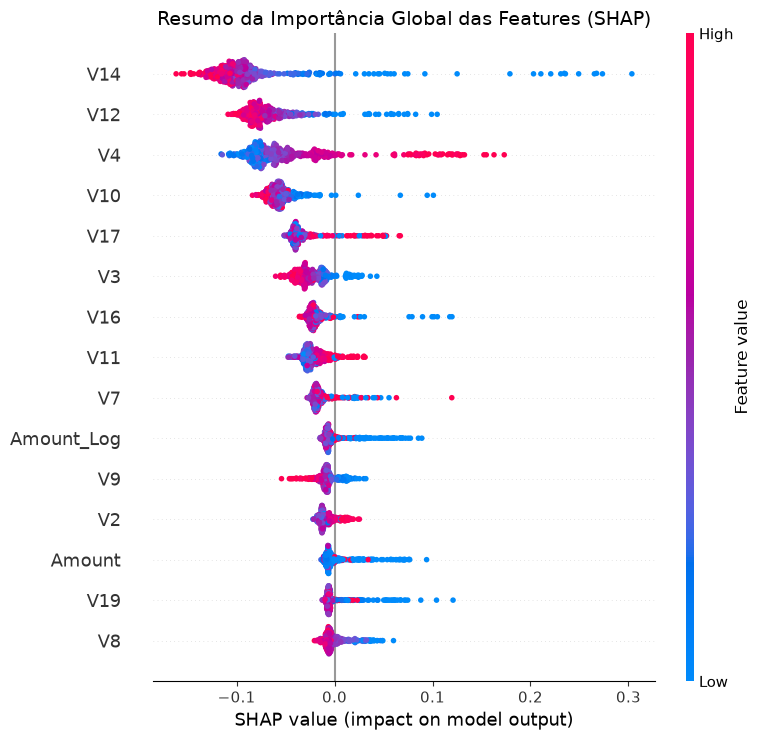

In [17]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_fraud, X_shap, show=False, max_display=15)
plt.title('Resumo da Importância Global das Features (SHAP)', fontsize=14)
plt.tight_layout()
plt.show()

Analisando amostra 442 do subset SHAP
Features da amostra: {'Time': 141475.0, 'V1': 0.0945683363334399, 'V2': 0.0187004765169157, 'V3': -0.0100872381953855, 'V4': -2.13951074532221, 'V5': 0.54135530072922, 'V6': -0.684572527323399, 'V7': 1.43504752679233, 'V8': -0.762568265621011, 'V9': -0.45600880136137, 'V10': 0.151528123838466, 'V11': -1.10082414533134, 'V12': -0.804220396614663, 'V13': -0.673613604445376, 'V14': 0.0126611357638224, 'V15': 0.30701618763255, 'V16': -2.43391132611611, 'V17': -0.26306290053307, 'V18': 1.24748861634774, 'V19': -0.583127147114591, 'V20': -0.491893028194259, 'V21': -0.311453625069251, 'V22': -0.0441754442455627, 'V23': -0.300696671815555, 'V24': 0.557279344692818, 'V25': 0.301456903017171, 'V26': -0.704579097945589, 'V27': -0.359100312918743, 'V28': -0.438853758270367, 'Amount': 68.64, 'Amount_Log': 0.6583853017195497, 'Time_Log': 0.74188543041881}


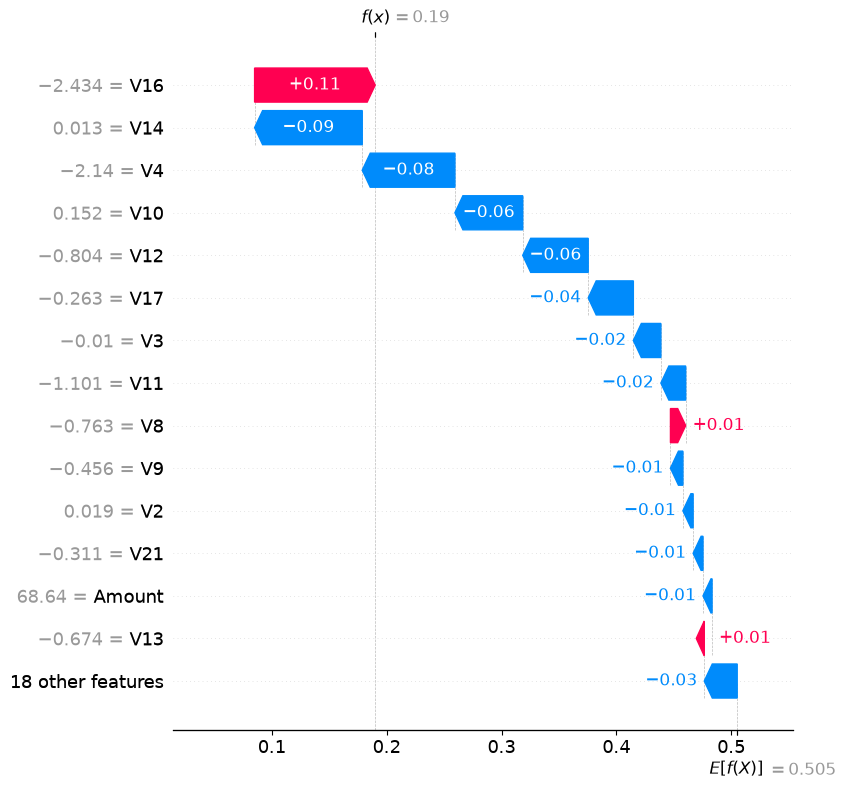

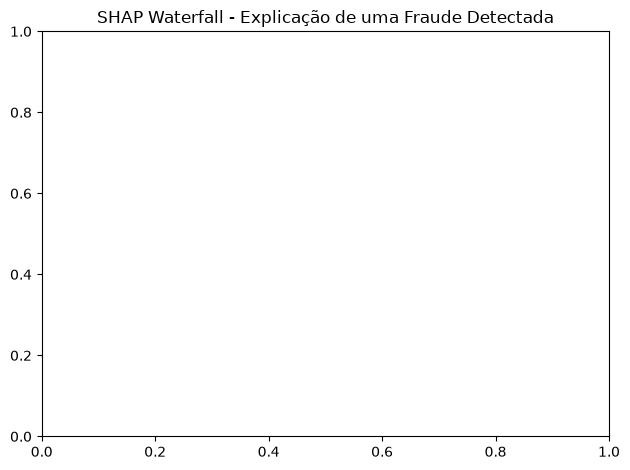

In [18]:
shap_idx = np.random.choice(len(X_shap), 1, replace=False)[0]
print(f"Analisando amostra {shap_idx} do subset SHAP")
print(f"Features da amostra: {X_shap.iloc[shap_idx].to_dict()}")
sv = shap_values_fraud[shap_idx]
ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    ev = float(ev[1]) if len(ev) > 1 else float(ev[0])
else:
    ev = float(ev)
explanation = shap.Explanation(values=sv, base_values=ev, data=X_shap.iloc[shap_idx].values, feature_names=X_shap.columns.tolist())
shap.waterfall_plot(explanation, max_display=15)
plt.title('SHAP Waterfall - Explicação de uma Fraude Detectada')
plt.tight_layout()
plt.show()

Top features que contribuíram para a explicação da fraude:
feature  shap_value     value
    V16    0.105003 -2.433911
    V14   -0.093736  0.012661
     V4   -0.080681 -2.139511
    V10   -0.059031  0.151528
    V12   -0.057039 -0.804220
    V17   -0.039301 -0.263063
     V3   -0.023959 -0.010087
    V11   -0.021618 -1.100824
     V8    0.013272 -0.762568
     V9   -0.010838 -0.456009


<Figure size 1000x600 with 0 Axes>

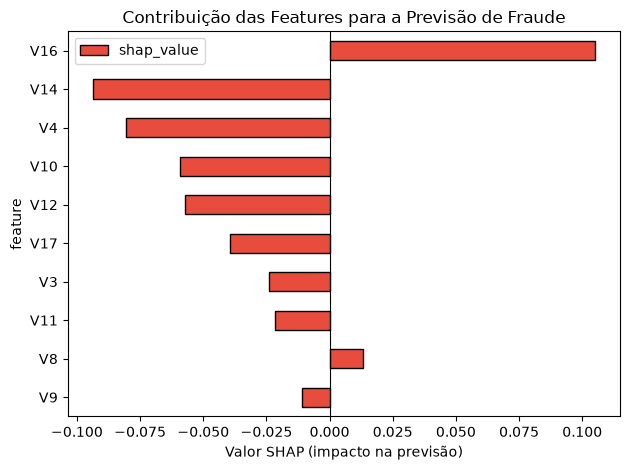

In [19]:
sv = shap_values_fraud[shap_idx]
feature_contributions = pd.DataFrame({
    'feature': X_shap.columns,
    'shap_value': sv,
    'value': X_shap.iloc[shap_idx].values
}).sort_values('shap_value', key=abs, ascending=False).head(10)
print('Top features que contribuíram para a explicação da fraude:')
print(feature_contributions.to_string(index=False))
plt.figure(figsize=(10, 6))
feature_contributions.plot(x='feature', y='shap_value', kind='barh', color='#e74c3c', edgecolor='black')
plt.xlabel('Valor SHAP (impacto na previsão)')
plt.title('Contribuição das Features para a Previsão de Fraude')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 11. Conclusão

In [20]:
print("="*70)
print("RESUMO FINAL DO PROJETO")
print("="*70)
print(f"1. O dataset contém {len(df)} transações, das quais {df['Class'].sum()} são fraudes.")
print(f"2. Taxa de fraude: {df['Class'].mean()*100:.3f}%")
print("3. A acurácia é enganosa: um modelo que sempre prevê 'normal' teria ~99,8%.")
print("4. Métrica principal: F1 Score para a classe de fraude.")
best_row = results_df.iloc[0]
print("5. Melhor modelo: " + str(best_row['model_name']) + " (F1=" + str(round(best_row['f1'],4)) + ", AUC-ROC=" + str(round(best_row['auc_roc'],4)) + ")")
print("6. Ajuste de limiar pode melhorar ainda mais o F1.")
print("7. SHAP explica quais features mais influenciam cada decisão.")
print("="*70)

RESUMO FINAL DO PROJETO
1. O dataset contém 284807 transações, das quais 492 são fraudes.
2. Taxa de fraude: 0.173%
3. A acurácia é enganosa: um modelo que sempre prevê 'normal' teria ~99,8%.
4. Métrica principal: F1 Score para a classe de fraude.
5. Melhor modelo: RF - Baseline (F1=0.8571, AUC-ROC=0.9573)
6. Ajuste de limiar pode melhorar ainda mais o F1.
7. SHAP explica quais features mais influenciam cada decisão.
